<a href="https://colab.research.google.com/github/s006aj/DATA-SCIENCE-/blob/main/abc_company_employee_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IMPORTING LIBRARIES

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

IMPORTING DATA

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


DISPLAYING DATA

In [3]:

sheet_url = "https://docs.google.com/spreadsheets/d/1aDiNQMStFPyY7mJEgt2sIAApFrG2uE19/export?format=csv"

df = pd.read_csv(sheet_url)
df.head()

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0,PG,25,06-Feb,180,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99,SF,25,06-Jun,235,Marquette,6796117.0
2,John Holland,Boston Celtics,30,SG,27,06-May,205,Boston University,NaN
3,R.J. Hunter,Boston Celtics,28,SG,22,06-May,185,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8,PF,29,06-Oct,231,NaN,5000000.0


DATA PREPROCESSING

In [4]:
np.random.seed(42)
df['height']=np.random.randint(150,181,size=len(df))
df.head()

,Name,Team,Number,Position,Age,Height,Weight,College,Salary,height
0,Avery Bradley,Boston Celtics,0,PG,25,06-Feb,180,Texas,7730337.0,156
1,Jae Crowder,Boston Celtics,99,SF,25,06-Jun,235,Marquette,6796117.0,169
2,John Holland,Boston Celtics,30,SG,27,06-May,205,Boston University,NaN,178
3,R.J. Hunter,Boston Celtics,28,SG,22,06-May,185,Georgia State,1148640.0,164
4,Jonas Jerebko,Boston Celtics,8,PF,29,06-Oct,231,NaN,5000000.0,160


DETERMINING DISTRIBUTION OF EMPLOYESS ACROSS TEAM

In [5]:
team_count =df['Team'].value_counts()
team_percentage = df['Team'].value_counts(normalize=True)*100



In [6]:
team_summary = pd.DataFrame({'counts':team_count,'percentage':team_percentage})
print(team_summary)

                        counts  percentage
Team                                      
New Orleans Pelicans        19    4.148472
Memphis Grizzlies           18    3.930131
Utah Jazz                   16    3.493450
Milwaukee Bucks             16    3.493450
New York Knicks             16    3.493450
Boston Celtics              15    3.275109
Los Angeles Clippers        15    3.275109
Los Angeles Lakers          15    3.275109
Phoenix Suns                15    3.275109
Sacramento Kings            15    3.275109
Brooklyn Nets               15    3.275109
Philadelphia 76ers          15    3.275109
Toronto Raptors             15    3.275109
Golden State Warriors       15    3.275109
Indiana Pacers              15    3.275109
Detroit Pistons             15    3.275109
Cleveland Cavaliers         15    3.275109
Chicago Bulls               15    3.275109
Houston Rockets             15    3.275109
San Antonio Spurs           15    3.275109
Atlanta Hawks               15    3.275109
Dallas Mave

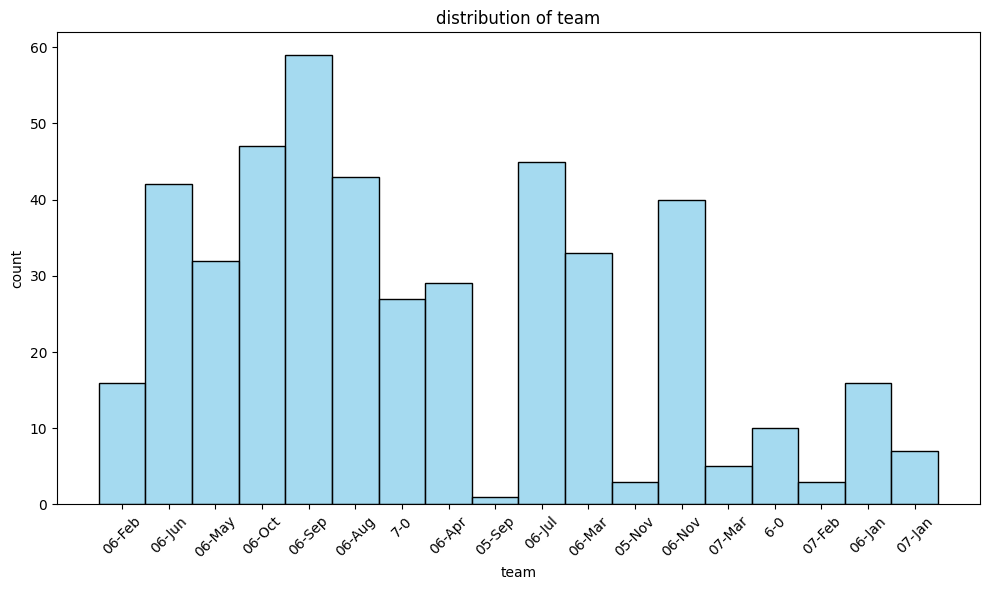

In [41]:
plt.figure(figsize=(10,6))
sns.histplot(df['Height'], bins=15, color='skyblue', edgecolor='black')
plt.title('distribution of team')
plt.xlabel('team')
plt.ylabel('count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()




SEGREGATING EMPLOYESBASED ON THEIR POSITION

Position
SG    102
PF    100
PG     92
SF     85
C      79
Name: count, dtype: int64


/tmp/ipykernel_974/3402817877.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Position', data=df, order=position_count.index, palette='viridis')


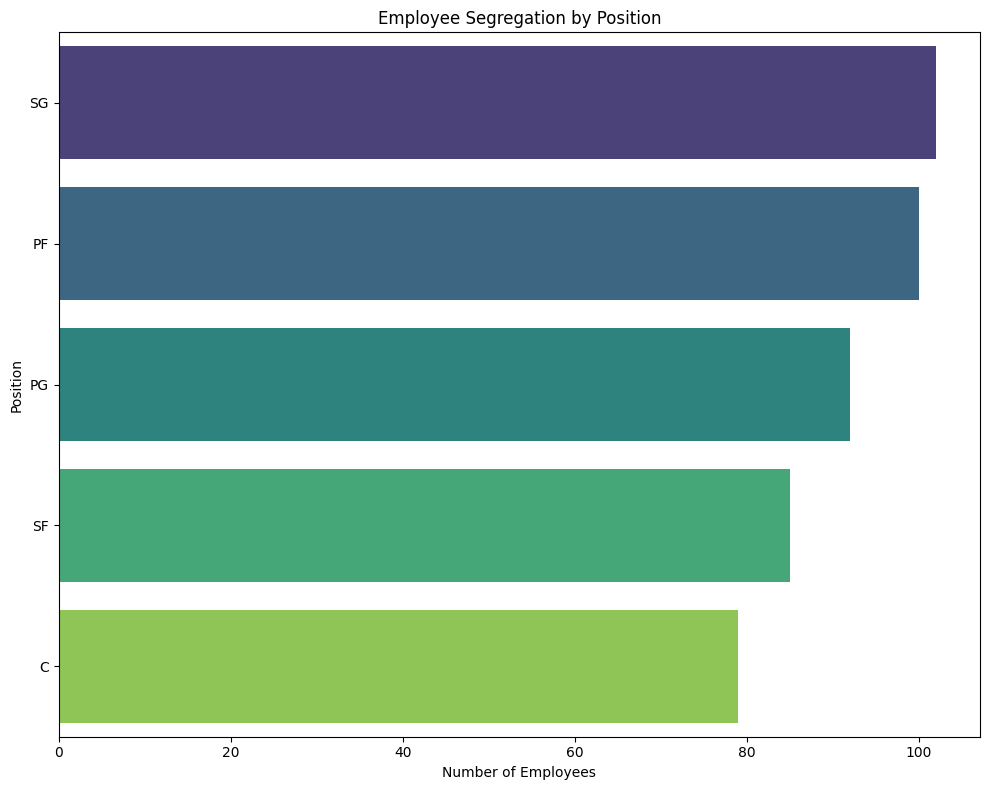

In [16]:
position_count= df['Position'].value_counts()
print(position_count)
plt.figure(figsize=(10, 8))
sns.countplot(y='Position', data=df, order=position_count.index, palette='viridis')
plt.title('Employee Segregation by Position')
plt.xlabel('Number of Employees')
plt.ylabel('Position')
plt.tight_layout()
plt.show()

IDENTIFYING PREDOMINANT AGE GROUPS

25-29


/tmp/ipykernel_974/1469199726.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='age_group',data=df,palette ='viridis',order=labels)


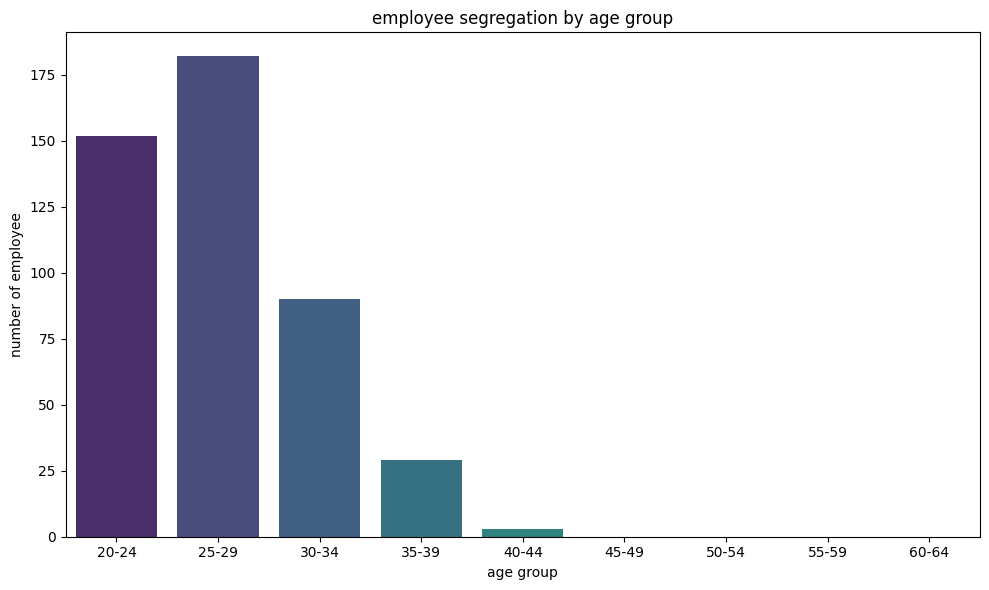

In [23]:
bins=[20,25,30,35,40,45,50,55,60,65]
labels=['20-24','25-29','30-34','35-39','40-44','45-49','50-54','55-59','60-64']
df['age_group']=pd.cut(df['Age'],bins=bins,labels=labels,right=False)
predominant_age= df['age_group'].value_counts().idxmax()
print(predominant_age)
plt.figure(figsize=(10,6))
sns.countplot(x='age_group',data=df,palette ='viridis',order=labels)
plt.title('employee segregation by age group')
plt.xlabel('age group')
plt.ylabel('number of employee')
plt.tight_layout()
plt.show()


TEAM AND POSITION WITH HIGHEST SALARY

team with highest salary:Cleveland Cavaliers (106988689)
position with highest salary:C (466377332)


/tmp/ipykernel_974/1095554701.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=team_salary.index,y=team_salary.values,palette='viridis')


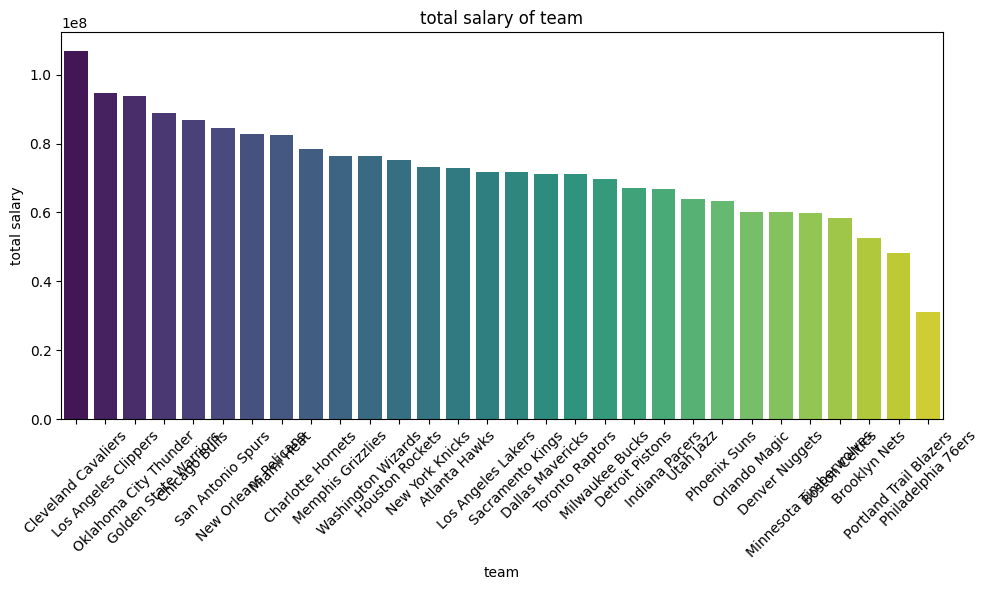

In [43]:
team_salary=df.groupby('Team')['Salary'].sum().sort_values(ascending=False)
position_salary=df.groupby('Position')['Salary'].sum().sort_values(ascending=False)
print(f'team with highest salary:{team_salary.index[0]} ({team_salary.iloc[0]:.0f})')
print(f'position with highest salary:{position_salary.index[0]} ({position_salary.iloc[0]:.0f})')
plt.figure(figsize=(10,6))
sns.barplot(x=team_salary.index,y=team_salary.values,palette='viridis')
plt.title('total salary of team')
plt.xlabel('team')
plt.ylabel('total salary')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

CORRELATION BETWEEN AGE AND SALARY

correlation between age and salary :0.21


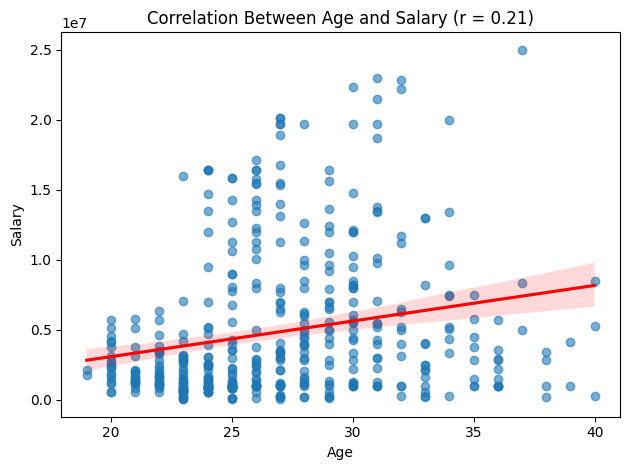

In [39]:
correlation=df['Age'].corr(df['Salary'])
print(f'correlation between age and salary :{correlation:.2f}')

sns.regplot(x='Age', y='Salary', data=df, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title(f'Correlation Between Age and Salary (r = {correlation:.2f})')
plt.xlabel('Age')
plt.ylabel('Salary')
plt.tight_layout()
plt.show()